# Snowball Strategy

In [1]:
from datetime import UTC, datetime, timedelta
from itertools import pairwise
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
from aws import AthenaDataSource
from core import (
    BacktestTaskDefinition,
    CandleGranularity,
    CurrencyPair,
    EventBus,
    InMemoryTaskRegistry,
    LogLevel,
    RecordingEventHandler,
    StrategyEvent,
    StrategyParameters,
    TaskManager,
    TaskProfilingConfig,
    TickGranularity,
    TickGranularityFilter,
    TqdmProgressReporter,
    configure_logging,
)
from matplotlib.patches import Rectangle
from snowball import SnowballStrategy

configure_logging(level=LogLevel.WARNING)


<Logger core (WARNING)>

## Parameters

In [ ]:
INSTRUMENT = CurrencyPair.of("USD_JPY")
START_AT = datetime(2026, 1, 1, tzinfo=UTC)
END_AT = datetime(2026, 1, 31, 23, 59, 59, 999999, tzinfo=UTC)
SAMPLE_GRANULARITY = TickGranularity.TICK
CHART_DAY_AGGS_THRESHOLD_DAYS = 31
PROFILE_DIR = Path("profiles") / "snowball"
LOCAL_TIMEZONE = datetime.now().astimezone().tzinfo

data_source = AthenaDataSource.from_env().with_filters(
    TickGranularityFilter.of(SAMPLE_GRANULARITY),
)

parameters = SnowballStrategy.normalize_parameters(
    StrategyParameters.of(
        sizing={
            "base_units": "1000",
        },
        grid={
            "max_retracements_per_layer": 10,
            "max_layers": 10,
            "refill": {
                "enabled": True,
            },
        },
        cycle={
            "hedging_enabled": True,
            "reseed_when_all_positions_pending_rebuild": True,
        },
        forward={
            "take_profit_pips": "20",
        },
        counter={
            "interval": {
                # choices: "constant", "additive", "subtractive"
                #          "multiplicative", "divisive", "manual"
                "mode": "divisive",
                "head_pips": "30",
                "tail_pips": "10",
                "gamma": "1.3",
            },
            "take_profit": {"mode": "weighted_avg"},
        },
        stop_loss={
            "enabled": True,
            # choices: "auto", "distance"
            "mode": "auto",
        },
        rebuild={
            "enabled": True,
            "price": {
                # choices: "original_entry_price", "stop_loss_exit_price"
                "entry_price_mode": "stop_loss_exit_price",
            },
            "stop_loss": {
                # choices: "same_price", "same_distance", "manual_distance"
                "mode": "same_distance",
            },
            "take_profit": {
                # choices: "same_price", "same_distance", "progressive_distance"
                "mode": "same_distance"
            },
        },
        protection={
            "shrink_enabled": False,
            "shrink_start_margin_percent": "70",
            "shrink_target_margin_percent": "50",
            "emergency_enabled": False,
            "emergency_margin_percent": "95",
        },
        account={
            "currency": "USD",
            "balance": {
                "amount": "10000",
                "currency": "USD",
            },
            "margin_rate": "0.04",
            "quote_to_account_rate": "1",
        },
    )
)


## Executuin

In [3]:
definition = BacktestTaskDefinition(
    name=f"{INSTRUMENT} Snowball Athena backtest",
    instrument=INSTRUMENT,
    start_at=START_AT,
    end_at=END_AT,
    parameters=parameters,
)

strategy = SnowballStrategy(
    name="snowball",
    parameters=definition.parameters,
)

recorder = RecordingEventHandler(event_class=StrategyEvent)
event_bus = EventBus(handlers=[recorder])

with TaskManager(
    registry=InMemoryTaskRegistry(),
    event_bus=event_bus,
    profiling=TaskProfilingConfig(
        cprofile=False,
        cprofile_output_path=PROFILE_DIR,
        pyinstrument=False,
        pyinstrument_output_path=PROFILE_DIR,
    ),
) as manager:
    run = manager.start_backtest(definition, data_source=data_source, strategy=strategy)
    final_task = run.wait(progress=TqdmProgressReporter())

print(f"Task {final_task.id} finished with status: {final_task.status.value}")
print(f"Events recorded: {len(recorder.events)}")

USD_JPY Snowball Athena backtest: 100%|██████████| , current=2026-01-10 15:59:59 PST, status=completed [04:06<00:00, 3500.21s/s] 

Task 019f51c5-7b5b-741b-81ea-ad0247c16936 finished with status: completed
Events recorded: 176


## Results

In [4]:
events = recorder.events


def local_datetime(value):
    return value.astimezone(LOCAL_TIMEZONE) if value is not None else None


def meta(event: StrategyEvent, key: str):
    return event.metadata.get(key)


signals_df = pd.DataFrame(
    {
        "timestamp": local_datetime(event.timestamp),
        "action": event.action.value,
        "display_id": event.display_id,
        "units": float(event.units) if event.units is not None else None,
        "price": str(event.price) if event.price is not None else None,
        "rule": event.reason.rule_id,
        "cycle_id": meta(event, "cycle_id"),
        "direction": meta(event, "direction"),
        "entry_role": meta(event, "entry_role"),
        "layer_number": meta(event, "layer_number"),
        "slot_number": meta(event, "slot_number"),
        "build_number": meta(event, "build_number"),
        "close_reason": meta(event, "close_reason"),
        "is_rebuild": meta(event, "is_rebuild"),
        "planned_entry_price": meta(event, "planned_entry_price"),
        "filled_entry_price": meta(event, "filled_entry_price"),
        "planned_take_profit_price": meta(event, "planned_take_profit_price"),
        "filled_take_profit_price": meta(event, "filled_take_profit_price"),
        "planned_stop_loss_price": meta(event, "planned_stop_loss_price"),
        "filled_stop_loss_price": meta(event, "filled_stop_loss_price"),
        "planned_rebuild_price": meta(event, "planned_rebuild_price"),
        "filled_rebuild_price": meta(event, "filled_rebuild_price"),
        "realized_pl": meta(event, "realized_pl"),
    }
    for event in events
)
events_df = signals_df
signals_df


,timestamp,action,display_id,units,price,rule,cycle_id,direction,entry_role,layer_number,...,is_rebuild,planned_entry_price,filled_entry_price,planned_take_profit_price,filled_take_profit_price,planned_stop_loss_price,filled_stop_loss_price,planned_rebuild_price,filled_rebuild_price,realized_pl
0,2026-01-01 14:12:58-07:00,open_trade,C1L1R0B1,1000.0,156.71 JPY,snowball.open,1,long,initial,1,...,False,156.71 JPY,156.71 JPY,156.91 JPY,NaN,156.41 JPY,NaN,NaN,NaN,NaN
1,2026-01-01 14:12:58-07:00,open_trade,C2L1R0B1,1000.0,156.70 JPY,snowball.open,2,short,initial,1,...,False,156.70 JPY,156.70 JPY,156.50 JPY,NaN,157.00 JPY,NaN,NaN,NaN,NaN
2,2026-01-01 15:34:54-07:00,close_trade,C2L1R0B1,1000.0,157.02 JPY,snowball.close.stop_loss,2,short,initial,1,...,False,156.70 JPY,156.70 JPY,156.50 JPY,NaN,157.00 JPY,157.02 JPY,157.00 JPY,NaN,-322.00 JPY
3,2026-01-01 15:34:55-07:00,open_trade,C2L1R0B2,1000.0,157.00 JPY,snowball.open.rebuild,2,short,initial,1,...,True,157.00 JPY,157.00 JPY,156.80 JPY,NaN,157.30 JPY,NaN,157.00 JPY,157.00 JPY,NaN
4,2026-01-01 15:35:12-07:00,close_trade,C2L1R0B2,1000.0,156.76 JPY,snowball.close.take_profit,2,short,initial,1,...,False,157.00 JPY,157.00 JPY,156.80 JPY,156.76 JPY,157.30 JPY,NaN,NaN,NaN,238.00 JPY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171,2026-01-09 08:05:54-07:00,close_trade,C45L1R0B2,1000.0,158.08 JPY,snowball.close.stop_loss,45,short,initial,1,...,False,157.78 JPY,157.78 JPY,157.58 JPY,NaN,158.08 JPY,158.08 JPY,158.08 JPY,NaN,-304.00 JPY
172,2026-01-09 08:05:55-07:00,open_trade,C45L1R0B3,1000.0,158.08 JPY,snowball.open.rebuild,45,short,initial,1,...,True,158.08 JPY,158.08 JPY,157.88 JPY,NaN,158.38 JPY,NaN,158.08 JPY,158.08 JPY,NaN
173,2026-01-09 08:52:06-07:00,close_trade,C45L1R0B3,1000.0,157.88 JPY,snowball.close.take_profit,45,short,initial,1,...,False,158.08 JPY,158.08 JPY,157.88 JPY,157.88 JPY,158.38 JPY,NaN,NaN,NaN,202.00 JPY
174,2026-01-09 08:52:17-07:00,close_trade,C48L1R0B2,1000.0,157.87 JPY,snowball.close.take_profit,48,short,initial,1,...,False,158.07 JPY,158.07 JPY,157.87 JPY,157.87 JPY,158.37 JPY,NaN,NaN,NaN,202.00 JPY


## Chart


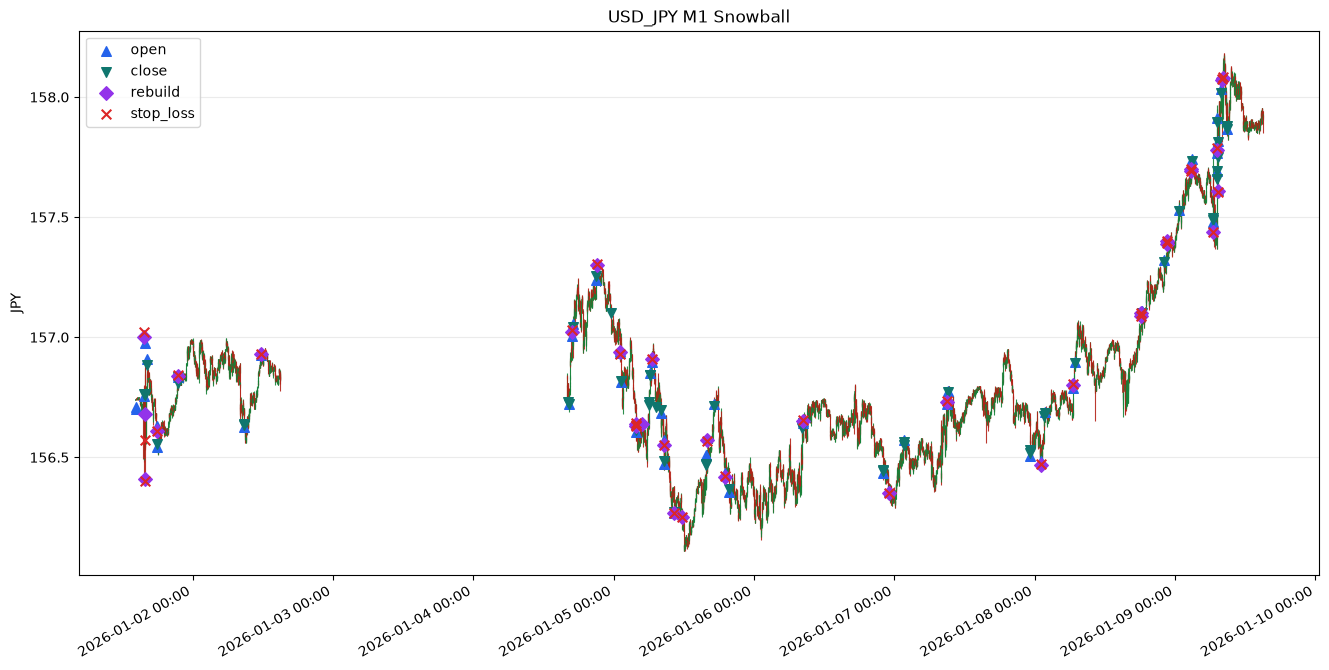

In [5]:
chart_granularity = (
    CandleGranularity.DAY
    if END_AT - START_AT > timedelta(days=CHART_DAY_AGGS_THRESHOLD_DAYS)
    else CandleGranularity.MINUTE_1
)

candles = tuple(
    data_source.candles(
        instrument=INSTRUMENT,
        granularity=chart_granularity,
        start_at=START_AT,
        end_at=END_AT,
    )
)

candles_df = pd.DataFrame(
    {
        "timestamp": local_datetime(candle.timestamp),
        "open": float(candle.open.amount),
        "high": float(candle.high.amount),
        "low": float(candle.low.amount),
        "close": float(candle.close.amount),
        "volume": candle.volume,
    }
    for candle in candles
)

fig, ax = plt.subplots(figsize=(16, 8))

if not candles_df.empty:
    x_values = mdates.date2num(candles_df["timestamp"])
    positive_deltas = [right - left for left, right in pairwise(x_values) if right > left]
    width = min(positive_deltas) * 0.8 if positive_deltas else 0.7
    if chart_granularity == CandleGranularity.MINUTE_1:
        width = min(width, 1 / 24 / 60 * 0.8)

    for x, row in zip(x_values, candles_df.itertuples(index=False), strict=False):
        color = "#16833a" if row.close >= row.open else "#b42318"
        ax.vlines(x, row.low, row.high, color=color, linewidth=0.8, alpha=0.9)
        lower = min(row.open, row.close)
        height = abs(row.close - row.open)
        if height == 0:
            ax.hlines(row.open, x - width / 2, x + width / 2, color=color, linewidth=1.2)
        else:
            ax.add_patch(
                Rectangle(
                    (x - width / 2, lower),
                    width,
                    height,
                    facecolor=color,
                    edgecolor=color,
                    linewidth=0.6,
                    alpha=0.75,
                )
            )


def truthy(value):
    return value is True or str(value).lower() in {"1", "true", "yes"}


def event_points(predicate):
    return [
        (local_datetime(event.timestamp), float(event.price.amount))
        for event in events
        if event.price is not None and predicate(event)
    ]


def scatter(points, *, label, marker, color):
    if not points:
        return
    timestamps, prices = zip(*points, strict=False)
    ax.scatter(timestamps, prices, label=label, marker=marker, color=color, s=48, zorder=5)


scatter(
    event_points(
        lambda event: event.action.value == "open_trade" and not truthy(meta(event, "is_rebuild"))
    ),
    label="open",
    marker="^",
    color="#2563eb",
)
scatter(
    event_points(
        lambda event: (
            event.action.value == "close_trade"
            and meta(event, "close_reason") != "stop_loss"
        )
    ),
    label="close",
    marker="v",
    color="#0f766e",
)
scatter(
    event_points(
        lambda event: event.action.value == "open_trade"
        and truthy(meta(event, "is_rebuild"))
    ),
    label="rebuild",
    marker="D",
    color="#9333ea",
)
scatter(
    event_points(lambda event: meta(event, "close_reason") == "stop_loss"),
    label="stop_loss",
    marker="x",
    color="#dc2626",
)

ax.set_title(f"{INSTRUMENT} {chart_granularity.value} Snowball")
ax.set_ylabel(str(INSTRUMENT.quote))
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M", tz=LOCAL_TIMEZONE))
ax.grid(True, axis="y", alpha=0.25)
handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(handles, labels, loc="best")
fig.autofmt_xdate()
plt.show()


In [6]:
profile = run.profile()
profile_outputs = {
    "cprofile": profile.cprofile_output_path,
    "pyinstrument": profile.pyinstrument_output_path,
}
if profile.cprofile_output_path is not None:
    profile_outputs["snakeviz"] = f"uv run snakeviz {profile.cprofile_output_path}"
    profile_outputs["tuna"] = f"uv run tuna {profile.cprofile_output_path}"
if profile.pyinstrument_output_path is not None:
    profile_outputs["html"] = f"open {profile.pyinstrument_output_path}"
profile_outputs

{'cprofile': None, 'pyinstrument': None}